In [2]:
import yfinance as yf
import pandas as pd

# Download Bitcoin data
df = yf.download("BTC-USD", start="2010-01-01", end="2025-12-31")

# Save data
df.to_csv("../Data/crypto_currency_project.csv")

# Show data
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800
2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200
2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700
2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600
2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4123 entries, 2014-09-17 to 2025-12-30
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, BTC-USD)   4123 non-null   float64
 1   (High, BTC-USD)    4123 non-null   float64
 2   (Low, BTC-USD)     4123 non-null   float64
 3   (Open, BTC-USD)    4123 non-null   float64
 4   (Volume, BTC-USD)  4123 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 193.3 KB


In [4]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
count,4123.000000,4123.000000,4123.000000,4123.000000,4.123000e+03
mean,26833.624457,27353.701131,26242.871164,26813.312957,2.162776e+10
std,31640.279891,32171.537323,31051.718086,31629.113290,2.288708e+10
min,178.102997,211.731003,171.509995,176.897003,5.914570e+06
25%,2697.255005,2770.045044,2605.835083,2690.935059,1.284595e+09
50%,10763.232422,11009.207031,10434.709961,10761.109375,1.708006e+10
75%,42235.638672,42998.707031,41365.187500,42198.601562,3.316961e+10
max,124752.531250,126198.070312,123196.046875,124752.140625,3.509679e+11


In [5]:
df.isnull().sum()

Price   Ticker 
Close   BTC-USD    0
High    BTC-USD    0
Low     BTC-USD    0
Open    BTC-USD    0
Volume  BTC-USD    0
dtype: int64

In [48]:
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

In [49]:
# Reset index 
if 'Date' not in df.columns:
    df.reset_index(inplace=True)

# Convert Date
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Convert Close
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')

# Remove nulls
df.dropna(inplace=True)

# Sort
df = df.sort_values(by='Date')

df.head()

Price,Date,Close,High,Low,Open,Volume
0,2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800
1,2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200
2,2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700
3,2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600
4,2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100


In [50]:
# Use only closing price
data = df['Close']

# Train-test split (last 30 days for testing)
train = data[:-30]
test = data[-30:]

print(len(train), len(test))

4093 30


In [51]:
from statsmodels.tsa.arima.model import ARIMA

# Build model
model = ARIMA(train, order=(1,1,1))

# Train model
model_fit = model.fit()

# Make predictions
predictions = model_fit.forecast(steps=30)

print(predictions)

4093    90412.611103
4094    90410.123737
4095    90410.461850
4096    90410.415890
4097    90410.422137
4098    90410.421288
4099    90410.421403
4100    90410.421388
4101    90410.421390
4102    90410.421389
4103    90410.421389
4104    90410.421389
4105    90410.421389
4106    90410.421389
4107    90410.421389
4108    90410.421389
4109    90410.421389
4110    90410.421389
4111    90410.421389
4112    90410.421389
4113    90410.421389
4114    90410.421389
4115    90410.421389
4116    90410.421389
4117    90410.421389
4118    90410.421389
4119    90410.421389
4120    90410.421389
4121    90410.421389
4122    90410.421389
Name: predicted_mean, dtype: float64


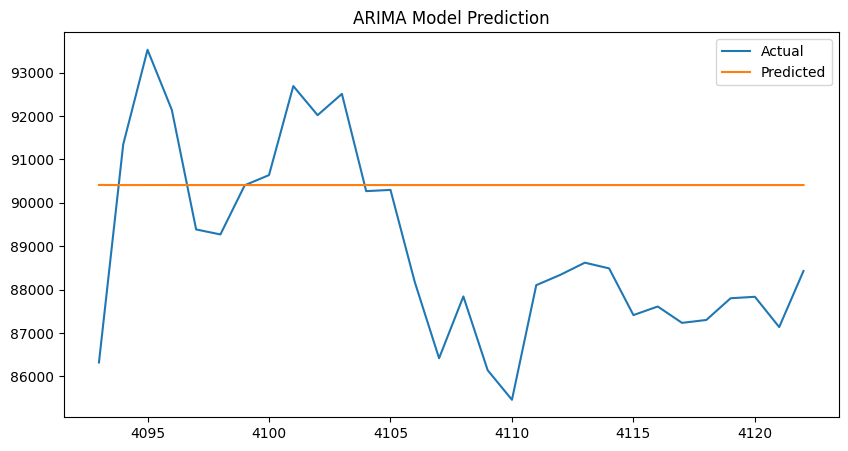

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

# Actual values
plt.plot(test.index, test.values, label='Actual')

# Predicted values
plt.plot(test.index, predictions, label='Predicted')

plt.title("ARIMA Model Prediction")
plt.legend()
plt.show()

In [53]:
from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(test, predictions)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)

MSE: 6542296.046982303
RMSE: 2557.7912438239177


In [54]:
# ---------- CREATE PROPHET DATA ----------
df_prophet = df[['Date', 'Close']].copy()

# Rename
df_prophet.columns = ['ds', 'y']

# ----------  CLEANING  ----------

# Convert ds to datetime STRICTLY
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'], errors='coerce', dayfirst=False)

# Remove invalid dates
df_prophet = df_prophet[df_prophet['ds'].notna()]

# Ensure y is numeric
df_prophet['y'] = pd.to_numeric(df_prophet['y'], errors='coerce')
df_prophet = df_prophet[df_prophet['y'].notna()]

# Remove duplicates
df_prophet = df_prophet.drop_duplicates(subset=['ds'])

# SORT 
df_prophet = df_prophet.sort_values('ds')

# RESET INDEX 
df_prophet = df_prophet.reset_index(drop=True)


In [55]:
# Split data
train = df_prophet[:-30]
test = df_prophet[-30:]

from prophet import Prophet

# Create model
model = Prophet()

# Train model
model.fit(train)

16:49:42 - cmdstanpy - INFO - Chain [1] start processing
16:49:48 - cmdstanpy - INFO - Chain [1] done processing


In [56]:
print(df_prophet['ds'].dtype)

datetime64[ns]


In [57]:
# Create future dataframe
future = model.make_future_dataframe(periods=30)

# Predict
forecast = model.predict(future)

forecast[['ds', 'yhat']].tail()

,ds,yhat
4118,2025-12-26,124768.968774
4119,2025-12-27,124845.808537
4120,2025-12-28,124950.224861
4121,2025-12-29,125140.376837
4122,2025-12-30,125169.858682


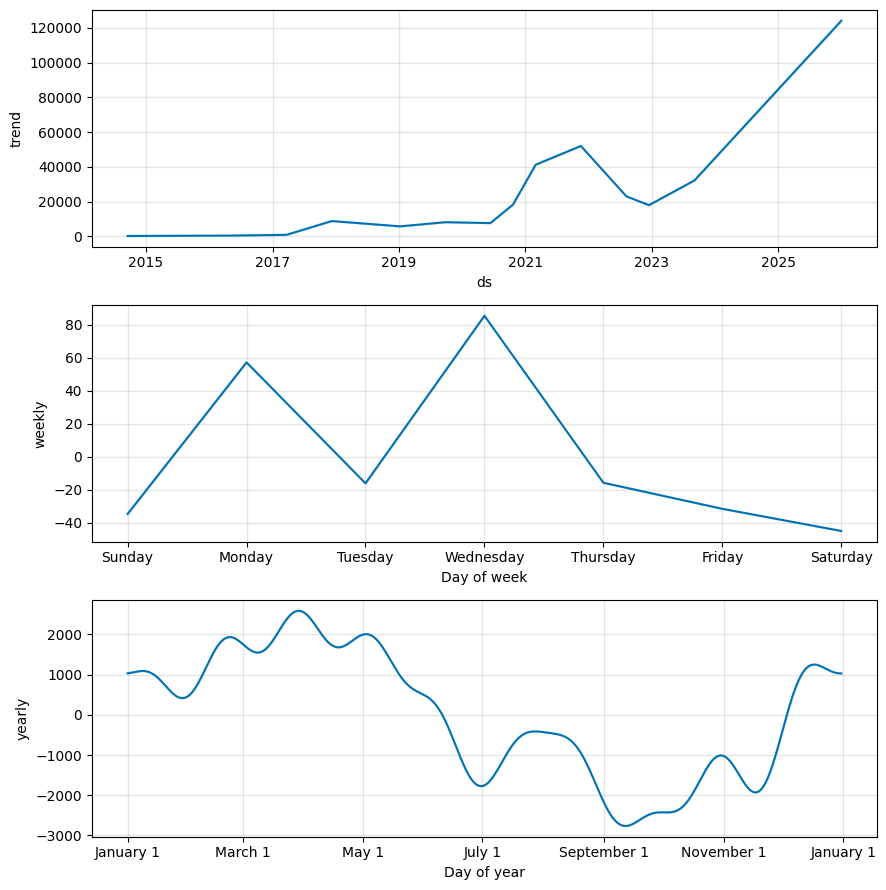

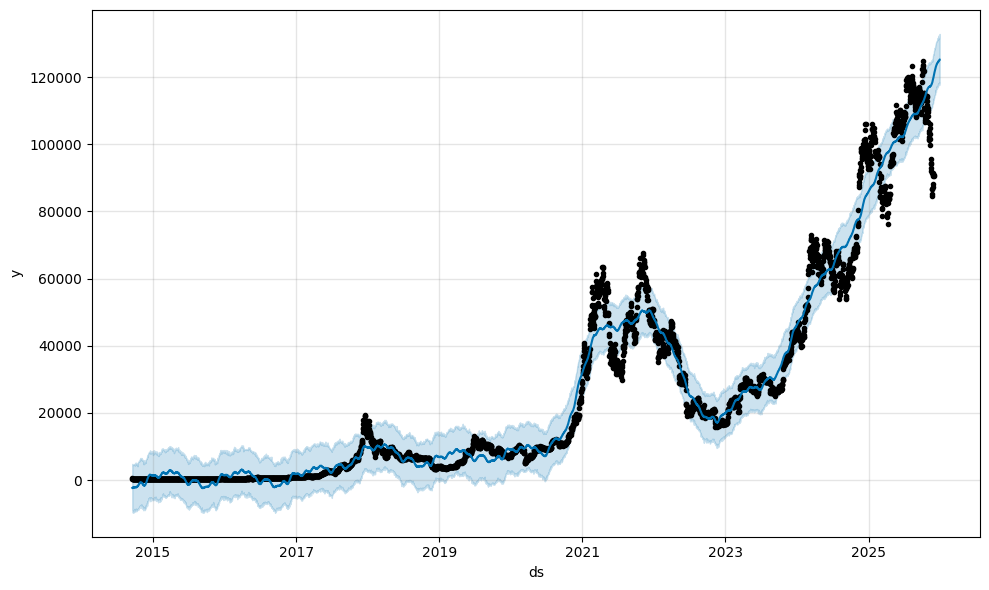

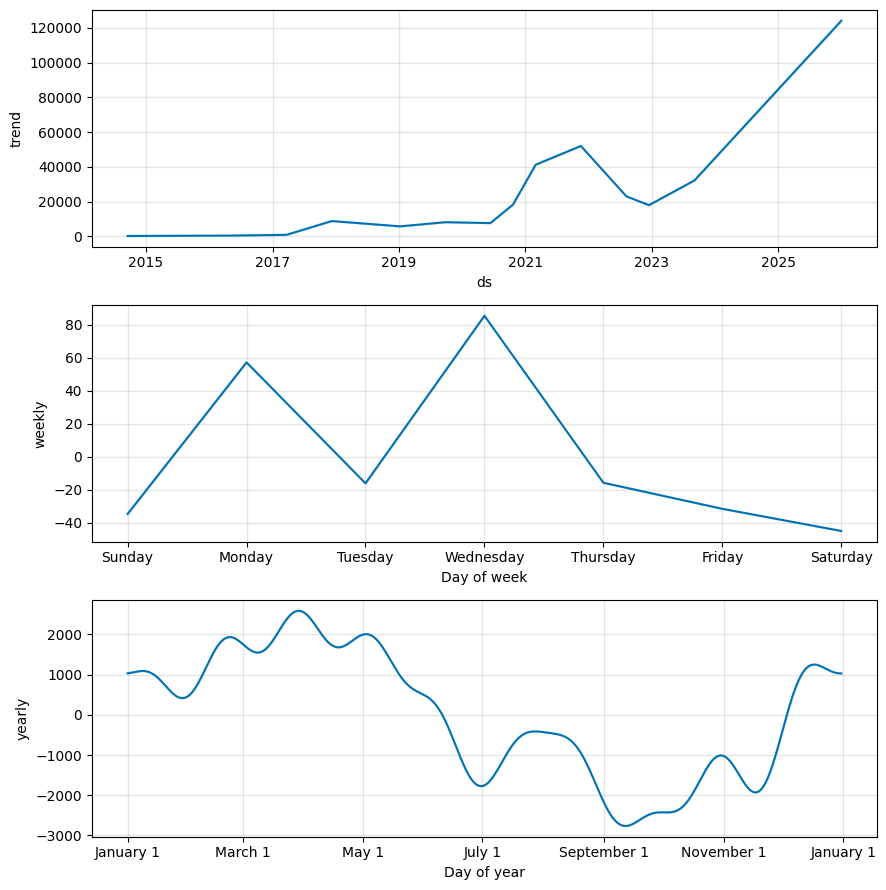

In [58]:
model.plot(forecast)
model.plot_components(forecast)

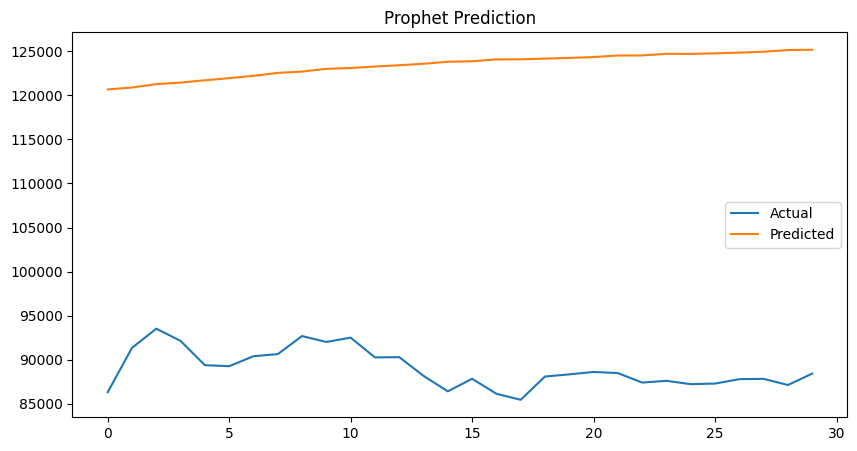

In [59]:
# Get last 30 predicted values
predictions = forecast['yhat'][-30:].values
actual = test['y'].values

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(actual, label="Actual")
plt.plot(predictions, label="Predicted")
plt.title("Prophet Prediction")
plt.legend()
plt.show()

In [60]:
from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(actual, predictions)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)

MSE: 1198472580.159996
RMSE: 34618.962725073034


In [61]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Use only Close price
data = df['Close'].values.reshape(-1,1)

# Scale data 
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [62]:
sequence_length = 10

X = []
y = []

for i in range(sequence_length, len(data_scaled)):
    X.append(data_scaled[i-sequence_length:i])
    y.append(data_scaled[i])

X, y = np.array(X), np.array(y)

print(X.shape, y.shape)

(4113, 10, 1) (4113, 1)


In [63]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [64]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()

model.add(LSTM(50, return_sequences=False, input_shape=(X.shape[1],1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

c:\Users\Hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [65]:
model.fit(X_train, y_train, epochs=10, batch_size=16)

Epoch 1/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.0011
Epoch 2/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 1.3931e-04
Epoch 3/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 1.3438e-04
Epoch 4/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 1.2396e-04
Epoch 5/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 1.1521e-04
Epoch 6/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 1.0868e-04
Epoch 7/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 9.3733e-05
Epoch 8/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 9.2594e-05
Epoch 9/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 8.3195e-05
Epoch 10/10
206/206 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 8.0968e-05


In [66]:
predictions = model.predict(X_test)

# Convert back to original scale
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test)

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step


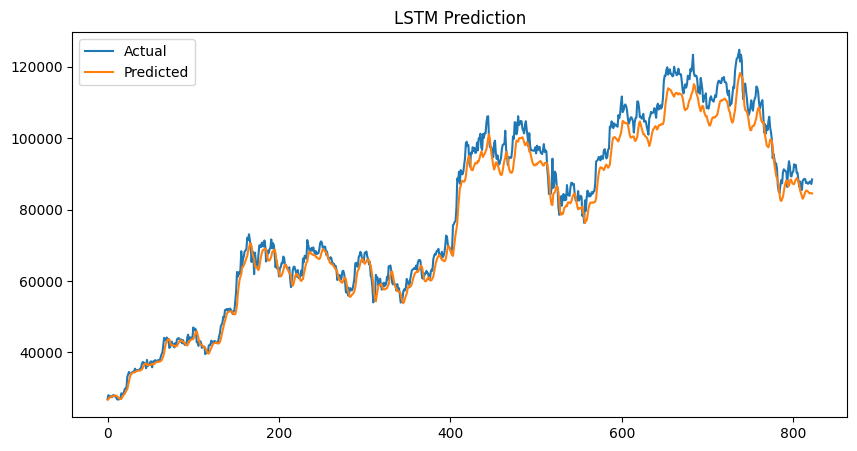

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test_actual, label="Actual")
plt.plot(predictions, label="Predicted")
plt.title("LSTM Prediction")
plt.legend()
plt.show()

In [68]:
from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(y_test_actual, predictions)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)

MSE: 15387300.462774975
RMSE: 3922.6649694786547
